In [2]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from __future__ import division, print_function
import numpy as np
from scipy.signal import butter, filtfilt, welch
from scipy.optimize import curve_fit


In [48]:
### CODE FOR STATE SWITCHING ###

np.random.seed(377)

start_scope()
delta_t = 0.1
sim_length = 4000
defaultclock.dt = delta_t * ms
### neuron model parameters ###
C = 200 * pF
g_leak = 10 * nS
tau = 20 * ms
V_rest = -60 * mV
reversal_P = 0 * mV
reversal_B = -70 * mV
reversal_A = -70 * mV
V_th = -50 * mV
V_reset = -60 * mV

### synapse parameters ###
synaptic_delay = 1 * ms

tau_syn_P = 2 * ms
tau_syn_A = 4 * ms
tau_syn_B = 1.5 * ms

tau_D = 250 * ms
eta_D = 0.18
e_AB = 0.5

# synapric conductance increases and connection probabilities
g_PP = 0.2 * nS
p_PP = 0.01

g_PA = 6 * nS
p_PA = 0.6

g_PB = 0.7 * nS
p_PB = 0.5

g_AP = 0.2 * nS
p_AP = 0.01

g_AA = 4 * nS
p_AA = 0.6

g_AB = 8 * nS
p_AB = 0.2

g_BP = 0.05 * nS
p_BP = 0.2

g_BA = 7 * nS
p_BA = 0.6

g_BB = 5 * nS
p_BB = 0.2

# population sizes
N_P = 8200
N_B = 135
N_A = 50

### currents ###
I_BG = 200 * pA

# I_ext = I_BG + I_i


### equations ###
eqs = '''
I_ext : amp (shared)
dv/dt = (g_leak*(V_rest - v) - (g_P*(v-reversal_P) + g_A*(v-reversal_A) + g_B*(v-reversal_B)) + I_ext)/C : volt (unless refractory)
dg_P/dt = -g_P/tau_syn_P : siemens
dg_A/dt = -g_A/tau_syn_A : siemens
dg_B/dt = -g_B/tau_syn_B : siemens
I_syn_B = g_B*(v - reversal_B) : amp
'''

pop_fraction = int(0.6 * N_P)

@network_operation(dt=delta_t * ms, when='start')
def current_pulse():
    group_B.I_ext = 200 * pA
    group_A.I_ext = 200 * pA
    group_P.I_ext = 200 * pA

    if 1000 * ms <= defaultclock.t <= 1010 * ms or 3000 * ms <= defaultclock.t <= 3010 * ms:
        group_P[0:pop_fraction].I_ext += np.random.uniform(0, 600) * pA
    
    elif 2000 * ms <= defaultclock.t <= 2010 * ms:
        group_P[0:pop_fraction].I_ext += -np.random.uniform(0, 500) * pA



#d -
### neurons groups ###
group_P = NeuronGroup(N_P, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')
group_A = NeuronGroup(N_A, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')
group_B = NeuronGroup(N_B, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')

### synapses ###
synapse_PP = Synapses(group_P, group_P, on_pre='g_P_post += g_PP', delay=synaptic_delay)
synapse_PP.connect(p=p_PP)

synapse_AP = Synapses(group_P, group_A, on_pre='g_P_post += g_AP', delay=synaptic_delay)
synapse_AP.connect(p=p_AP)

synapse_BP = Synapses(group_P, group_B, on_pre='g_P_post += g_BP', delay=synaptic_delay)
synapse_BP.connect(p=p_BP)

synapse_AA = Synapses(group_A, group_A, on_pre='g_A_post += g_AA', delay=synaptic_delay)
synapse_AA.connect(p=p_AA)

synapse_PA = Synapses(group_A, group_P, on_pre='g_A_post += g_PA', delay=synaptic_delay)
synapse_PA.connect(p=p_PA)

synapse_BA = Synapses(group_A, group_B, on_pre='g_A_post += g_BA', delay=synaptic_delay)
synapse_BA.connect(p=p_BA)

synapse_BB = Synapses(group_B, group_B, on_pre='g_B_post += g_BB', delay=synaptic_delay)
synapse_BB.connect(p=p_BB)


synapse_AB = Synapses(group_B, group_A, on_pre='''
                    g_B_post += g_AB*0.5
                      ''', method='exact', delay=synaptic_delay)
synapse_AB.connect(p=p_AB)

synapse_PB = Synapses(group_B, group_P, on_pre='g_B_post += g_PB', delay=synaptic_delay)
synapse_PB.connect(p=p_PB)

group_P.v = V_rest
group_B.v = V_rest
group_A.v = V_rest + (V_th - V_rest) * np.random.rand(N_A)

# Initialize synaptic conductances with small random values
group_P.g_P = 0.01 * nS * np.random.rand(N_P)
group_A.g_A = 0.01 * nS * np.random.rand(N_A)
group_B.g_B = 0.01 * nS * np.random.rand(N_B)

# Add PopulationRateMonitors
pop_rate_P = PopulationRateMonitor(group_P)
pop_rate_A = PopulationRateMonitor(group_A)
pop_rate_B = PopulationRateMonitor(group_B)

current_monitor = StateMonitor(group_P, 'I_syn_B', record=True)

statemon = StateMonitor(group_P, 'I_ext', record=True)
#eventmon = EventMonitor(group_B, ('pulse_on', 'I_i'), record=True)
network = Network(collect())

# Run the simulation
network.run(sim_length * ms)

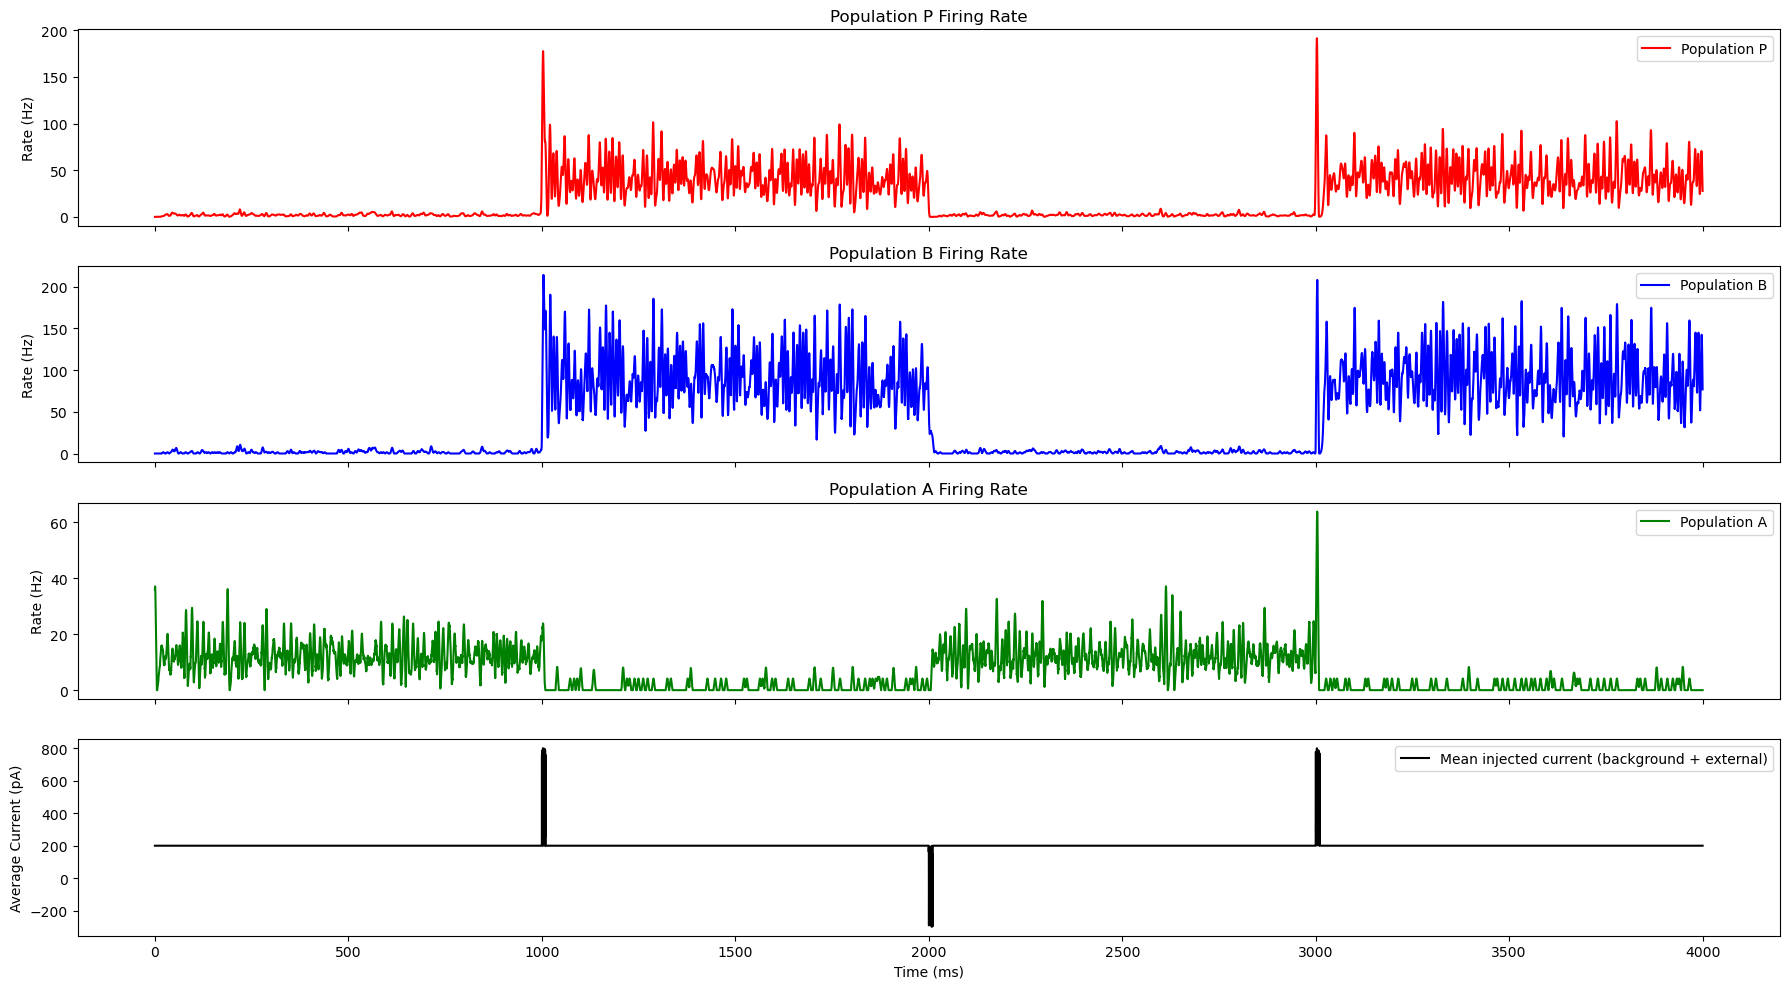

In [50]:
# Create a figure with 4 subplots (4 rows, 1 column)
fig, axs = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

# Population P firing rate
axs[0].plot(pop_rate_P.t / ms, pop_rate_P.smooth_rate(window="gaussian", width=2 * ms) / Hz,
            label='Population P', color="red")
axs[0].set_ylabel('Rate (Hz)')
axs[0].set_title('Population P Firing Rate')
axs[0].legend()

# Population B firing rate
axs[1].plot(pop_rate_B.t / ms, pop_rate_B.smooth_rate(window="gaussian", width=2 * ms) / Hz,
            label='Population B', color='blue')
axs[1].set_ylabel('Rate (Hz)')
axs[1].set_title('Population B Firing Rate')
axs[1].legend()

# Population A firing rate
axs[2].plot(pop_rate_A.t / ms, pop_rate_A.smooth_rate(window="gaussian", width=2 * ms) / Hz,
            label='Population A', color='green')
axs[2].set_ylabel('Rate (Hz)')
axs[2].set_title('Population A Firing Rate')
axs[2].legend(loc='upper right')

# Average external current I_ext over time
average_I_ext = np.mean(statemon.I_ext, axis=0)
axs[3].plot(statemon.t / ms, average_I_ext / amp * 1e12, label='Mean injected current (background + external)', color="black")
axs[3].set_xlabel('Time (ms)')
axs[3].set_ylabel('Average Current (pA)')
axs[3].legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


In [3]:
### CODE FOR SPONTANEUOS ACTIVITY ###

np.random.seed(377)

start_scope()
delta_t = 0.1
sim_length = 5000
defaultclock.dt = delta_t * ms
### neuron model parameters ###
C = 200 * pF
g_leak = 10 * nS
tau = 20 * ms
V_rest = -60 * mV
reversal_P = 0 * mV
reversal_B = -70 * mV
reversal_A = -70 * mV
V_th = -50 * mV
V_reset = -60 * mV

### synapse parameters ###
synaptic_delay = 1 * ms

tau_syn_P = 2 * ms
tau_syn_A = 4 * ms
tau_syn_B = 1.5 * ms

tau_D = 250 * ms
eta_D = 0.18
e_AB = 0.5

# synapric conductance increases and connection probabilities
g_PP = 0.2 * nS
p_PP = 0.01

g_PA = 6 * nS
p_PA = 0.6

g_PB = 0.7 * nS
p_PB = 0.5

g_AP = 0.2 * nS
p_AP = 0.01

g_AA = 4 * nS
p_AA = 0.6

g_AB = 8 * nS
p_AB = 0.2

g_BP = 0.05 * nS
p_BP = 0.2

g_BA = 7 * nS
p_BA = 0.6

g_BB = 5 * nS
p_BB = 0.2

# population sizes
N_P = 8200
N_B = 135
N_A = 50

### currents ###
I_BG = 200 * pA

# I_ext = I_BG + I_i


### equations ###
eqs = '''
I_ext : amp (shared)
dv/dt = (g_leak*(V_rest - v) - (g_P*(v-reversal_P) + g_A*(v-reversal_A) + g_B*(v-reversal_B)) + I_ext)/C : volt (unless refractory)
dg_P/dt = -g_P/tau_syn_P : siemens
dg_A/dt = -g_A/tau_syn_A : siemens
dg_B/dt = -g_B/tau_syn_B : siemens
I_syn_B = g_B*(v - reversal_B) : amp
'''


@network_operation(dt=delta_t * ms, when='start')
def current_pulse():
    if 1500 * ms <= defaultclock.t <= 1510 * ms:
        group_B[0:99].I_ext = np.random.uniform(0, 700) * pA
    else:
        group_B.I_ext = 200 * pA
        group_A.I_ext = 200 * pA
        group_P.I_ext = 200 * pA


#d -
### neurons groups ###
group_P = NeuronGroup(N_P, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')
group_A = NeuronGroup(N_A, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')
group_B = NeuronGroup(N_B, eqs, threshold='v>=V_th', reset='v=V_reset', refractory=1 * ms, method='euler')

### synapses ###
synapse_PP = Synapses(group_P, group_P, on_pre='g_P_post += g_PP', delay=synaptic_delay)
synapse_PP.connect(p=p_PP)

synapse_AP = Synapses(group_P, group_A, on_pre='g_P_post += g_AP', delay=synaptic_delay)
synapse_AP.connect(p=p_AP)

synapse_BP = Synapses(group_P, group_B, on_pre='g_P_post += g_BP', delay=synaptic_delay)
synapse_BP.connect(p=p_BP)

synapse_AA = Synapses(group_A, group_A, on_pre='g_A_post += g_AA', delay=synaptic_delay)
synapse_AA.connect(p=p_AA)

synapse_PA = Synapses(group_A, group_P, on_pre='g_A_post += g_PA', delay=synaptic_delay)
synapse_PA.connect(p=p_PA)

synapse_BA = Synapses(group_A, group_B, on_pre='g_A_post += g_BA', delay=synaptic_delay)
synapse_BA.connect(p=p_BA)

synapse_BB = Synapses(group_B, group_B, on_pre='g_B_post += g_BB', delay=synaptic_delay)
synapse_BB.connect(p=p_BB)

# to control depression
clamp_depr = 1
eqs_std_AB = '''
       g_ab : 1
       de_AB / dt = clamp_depr * (1. - e_AB) / tau_D : 1 (clock-driven)
       '''

synapse_AB = Synapses(group_B, group_A, model=eqs_std_AB, on_pre='''
                    g_B_post += g_AB*e_AB
                    e_AB = clip(e_AB - e_AB * eta_D, 0, 1)
                      ''', method='exact', delay=synaptic_delay)
synapse_AB.connect(p=p_AB)

synapse_PB = Synapses(group_B, group_P, on_pre='g_B_post += g_PB', delay=synaptic_delay)
synapse_PB.connect(p=p_PB)

group_P.v = V_rest
group_B.v = V_rest
group_A.v = V_rest + (V_th - V_rest) * np.random.rand(N_A)

# Initialize synaptic conductances with small random values
group_P.g_P = 0.01 * nS * np.random.rand(N_P)
group_A.g_A = 0.01 * nS * np.random.rand(N_A)
group_B.g_B = 0.01 * nS * np.random.rand(N_B)

# Add PopulationRateMonitors
pop_rate_P = PopulationRateMonitor(group_P)
pop_rate_A = PopulationRateMonitor(group_A)
pop_rate_B = PopulationRateMonitor(group_B)

current_monitor = StateMonitor(group_P, 'I_syn_B', record=True)

statemon = StateMonitor(group_B, 'I_ext', record=True)
eAB_monitor = StateMonitor(synapse_AB, 'e_AB', record=True)
#eventmon = EventMonitor(group_B, ('pulse_on', 'I_i'), record=True)
network = Network(collect())

# Run the simulation
network.run(sim_length * ms)

/Users/maxnowa/Library/Caches/cython/brian_extensions/_cython_magic_35824ef86305507537a03081279e76b6.cpp:1298:14: fatal error: 'cstdlib' file not found
 1298 |     #include <cstdlib>
      |              ^~~~~~~~~
1 error generated.
WARNING    Cannot use Cython, a test compilation failed: command '/usr/bin/clang++' failed with exit code 1 (CompileError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]
WARNING    Variable I_ext is a shared v

## 

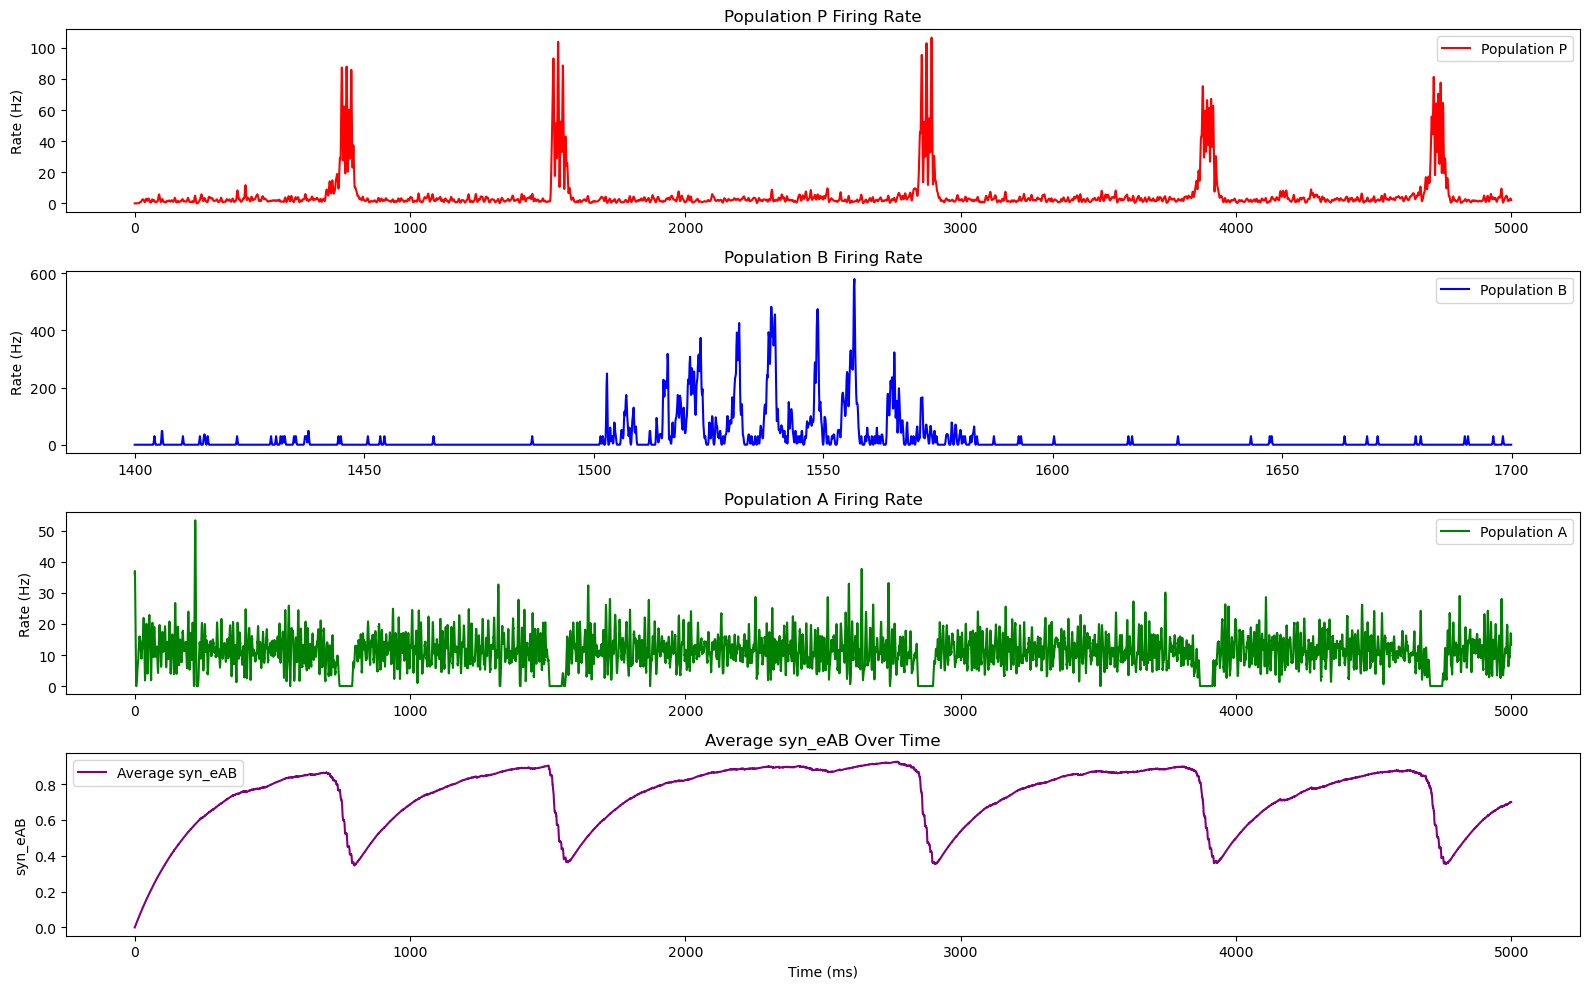

In [5]:
plt.figure(figsize=(16, 10))

# Population P Firing Rate
plt.subplot(4, 1, 1)
plt.plot(pop_rate_P.t / ms, pop_rate_P.smooth_rate(window="gaussian", width=2 * ms) / Hz,
         label='Population P', color="red")
plt.ylabel('Rate (Hz)')
plt.title('Population P Firing Rate')
plt.legend()

# Population B Firing Rate
plt.subplot(4, 1, 2)
plt.plot(pop_rate_B.t / ms, pop_rate_B.smooth_rate(window="gaussian", width=0.1 * ms) / Hz,
         label='Population B', color='blue')
plt.ylabel('Rate (Hz)')
plt.title('Population B Firing Rate')
plt.legend()

# Population A Firing Rate
plt.subplot(4, 1, 3)
plt.plot(pop_rate_A.t / ms, pop_rate_A.smooth_rate(window="gaussian", width=2 * ms) / Hz,
         label='Population A', color='green')
plt.ylabel('Rate (Hz)')
plt.title('Population A Firing Rate')
plt.legend(loc='upper right')

# syn_eAB Plot: Average synaptic depression variable over time
plt.subplot(4, 1, 4)
average_syn_eAB = np.mean(eAB_monitor.e_AB, axis=0)
plt.plot(eAB_monitor.t / ms, average_syn_eAB, label='Average syn_eAB', color='purple')
plt.xlabel('Time (ms)')
plt.ylabel('syn_eAB')
plt.title('Average syn_eAB Over Time')
plt.legend()

plt.tight_layout()
plt.show()


**Interpretation**:

* The peak indicates the onset of a sharp wave event, characterized by strong synchronization and elevated activity among pyramidal cells.
* Outside of SWRs, pyramidal cells are largely inactive, consistent with bistability (low-activity and high-activity states).

# 2.Population B Firing Rate
**Interpretation**:

* During SWRs, PV+ basket cells exhibit high firing rates to regulate pyramidal activity.
* This suggests that basket cells are crucial for the synchronization and termination of the SWR event.
* The firing activity is consistent with their role in providing inhibitory feedback to the pyramidal cells.


# 3. Population A Firing Rate
**Interpretation:**

* Anti-SWR cells maintain consistent inhibition in the network during non-SWR periods.
* Their decreased activity during SWRs suggests that they are disinhibited, allowing pyramidal cells to enter a high-activity state.
* This aligns with the disinhibition mechanism described in the paper, where reduced activity in anti-SWR cells facilitates SWR generation.



# *Overall* SWR Dynamics
*  **Trigger:**  The network enters an SWR event periodically, possibly due to spontaneous fluctuations or external input.

* **Peak Activity:** The firing rates of pyramidal and basket cells peak sharply, indicating synchronized activity across excitatory and inhibitory populations.

* **Termination:** The event concludes as basket cells suppress pyramidal activity, and anti-SWR cells regain control.

* **Bistability:** The network alternates between a low-activity resting state and a high-activity SWR state.

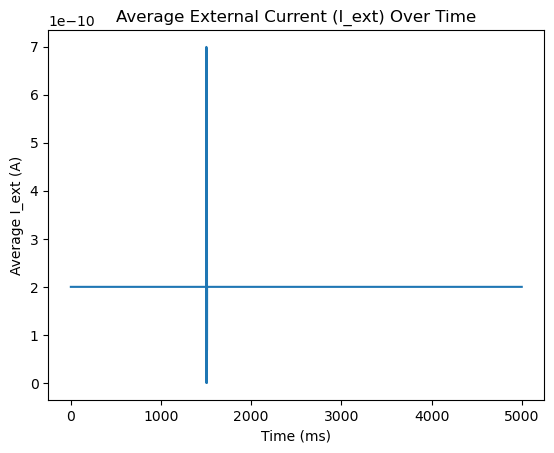

In [29]:
# Calculate the average I_ext over time
#average_I_ext = statemon.I_ext.mean(axis=0)

# Calculate the average I_ext over time
average_I_ext = np.mean(statemon.I_ext, axis=0)

# Plot the average I_ext over time
plt.plot(statemon.t / ms, average_I_ext / amp)
plt.xlabel('Time (ms)')
plt.ylabel('Average I_ext (A)')
plt.title('Average External Current (I_ext) Over Time')

plt.show()

In [30]:
"""Detect peaks in data based on their amplitude and other features."""

__author__ = "Marcos Duarte, https://github.com/demotu/BMC"
__version__ = "1.0.4"
__license__ = "MIT"


def detect_peaks(x, mph=None, mpd=1, threshold=0, edge='rising',
                 kpsh=False, valley=False, show=False, ax=None):
    """Detect peaks in data based on their amplitude and other features.
    Parameters
    ----------
    x : 1D array_like
        data.
    mph : {None, number}, optional (default = None)
        detect peaks that are greater than minimum peak height.
    mpd : positive integer, optional (default = 1)
        detect peaks that are at least separated by minimum peak distance (in
        number of data).
    threshold : positive number, optional (default = 0)
        detect peaks (valleys) that are greater (smaller) than `threshold`
        in relation to their immediate neighbors.
    edge : {None, 'rising', 'falling', 'both'}, optional (default = 'rising')
        for a flat peak, keep only the rising edge ('rising'), only the
        falling edge ('falling'), both edges ('both'), or don't detect a
        flat peak (None).
    kpsh : bool, optional (default = False)
        keep peaks with same height even if they are closer than `mpd`.
    valley : bool, optional (default = False)
        if True (1), detect valleys (local minima) instead of peaks.
    show : bool, optional (default = False)
        if True (1), plot data in matplotlib figure.
    ax : a matplotlib.axes.Axes instance, optional (default = None).
    Returns
    -------
    ind : 1D array_like
        indeces of the peaks in `x`.
    Notes
    -----
    The detection of valleys instead of peaks is performed internally by simply
    negating the data: `ind_valleys = detect_peaks(-x)`

    The function can handle NaN's
    See this IPython Notebook [1]_.
    References
    ----------
    .. [1] http://nbviewer.ipython.org/github/demotu/BMC/blob/master/notebooks/DetectPeaks.ipynb
    Examples
    --------
    # >>> from detect_peaks import detect_peaks
    # >>> x = np.random.randn(100)
    # >>> x[60:81] = np.nan
    # >>> # detect all peaks and plot data
    # >>> ind = detect_peaks(x, show=True)
    # >>> print(ind)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # set minimum peak height = 0 and minimum peak distance = 20
    # >>> detect_peaks(x, mph=0, mpd=20, show=True)
    # >>> x = [0, 1, 0, 2, 0, 3, 0, 2, 0, 1, 0]
    # >>> # set minimum peak distance = 2
    # >>> detect_peaks(x, mpd=2, show=True)
    # >>> x = np.sin(2*np.pi*5*np.linspace(0, 1, 200)) + np.random.randn(200)/5
    # >>> # detection of valleys instead of peaks
    # >>> detect_peaks(x, mph=0, mpd=20, valley=True, show=True)
    # >>> x = [0, 1, 1, 0, 1, 1, 0]
    # >>> # detect both edges
    # >>> detect_peaks(x, edge='both', show=True)
    # >>> x = [-2, 1, -2, 2, 1, 1, 3, 0]
    # >>> # set threshold = 2
    # >>> detect_peaks(x, threshold = 2, show=True)
    """

    x = np.atleast_1d(x).astype('float64')
    if x.size < 3:
        return np.array([], dtype=int)
    if valley:
        x = -x
    # find indexes of all peaks
    dx = x[1:] - x[:-1]
    # handle NaN's
    indnan = np.where(np.isnan(x))[0]
    if indnan.size:
        x[indnan] = np.inf
        dx[np.where(np.isnan(dx))[0]] = np.inf
    ine, ire, ife = np.array([[], [], []], dtype=int)
    if not edge:
        ine = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) > 0))[0]
    else:
        if edge.lower() in ['rising', 'both']:
            ire = np.where((np.hstack((dx, 0)) <= 0) & (np.hstack((0, dx)) > 0))[0]
        if edge.lower() in ['falling', 'both']:
            ife = np.where((np.hstack((dx, 0)) < 0) & (np.hstack((0, dx)) >= 0))[0]
    ind = np.unique(np.hstack((ine, ire, ife)))
    # handle NaN's
    if ind.size and indnan.size:
        # NaN's and values close to NaN's cannot be peaks
        ind = ind[np.in1d(ind, np.unique(np.hstack((indnan, indnan - 1, indnan + 1))), invert=True)]
    # first and last values of x cannot be peaks
    if ind.size and ind[0] == 0:
        ind = ind[1:]
    if ind.size and ind[-1] == x.size - 1:
        ind = ind[:-1]
    # remove peaks < minimum peak height
    if ind.size and mph is not None:
        ind = ind[x[ind] >= mph]
    # remove peaks - neighbors < threshold
    if ind.size and threshold > 0:
        dx = np.min(np.vstack([x[ind] - x[ind - 1], x[ind] - x[ind + 1]]), axis=0)
        ind = np.delete(ind, np.where(dx < threshold)[0])
    # detect small peaks closer than minimum peak distance
    if ind.size and mpd > 1:
        ind = ind[np.argsort(x[ind])][::-1]  # sort ind by peak height
        idel = np.zeros(ind.size, dtype=bool)
        for i in range(ind.size):
            if not idel[i]:
                # keep peaks with the same height if kpsh is True
                idel = idel | (ind >= ind[i] - mpd) & (ind <= ind[i] + mpd) \
                       & (x[ind[i]] > x[ind] if kpsh else True)
                idel[i] = 0  # Keep current peak
        # remove the small peaks and sort back the indexes by their occurrence
        ind = np.sort(ind[~idel])

    if show:
        if indnan.size:
            x[indnan] = np.nan
        if valley:
            x = -x
        _plot(x, mph, mpd, threshold, edge, valley, ax, ind)

    return ind


def _plot(x, mph, mpd, threshold, edge, valley, ax, ind):
    """Plot results of the detect_peaks function, see its help."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print('matplotlib is not available.')
    else:
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(8, 4))

        ax.plot(x, 'b', lw=1)
        if ind.size:
            label = 'valley' if valley else 'peak'
            label = label + 's' if ind.size > 1 else label
            ax.plot(ind, x[ind], '+', mfc=None, mec='r', mew=2, ms=8,
                    label='%d %s' % (ind.size, label))
            ax.legend(loc='best', framealpha=.5, numpoints=1)
        ax.set_xlim(-.02 * x.size, x.size * 1.02 - 1)
        ymin, ymax = x[np.isfinite(x)].min(), x[np.isfinite(x)].max()
        yrange = ymax - ymin if ymax > ymin else 1
        ax.set_ylim(ymin - 0.1 * yrange, ymax + 0.1 * yrange)
        ax.set_xlabel('Data #', fontsize=14)
        ax.set_ylabel('Amplitude', fontsize=14)
        mode = 'Valley detection' if valley else 'Peak detection'
        ax.set_title("%s (mph=%s, mpd=%d, threshold=%s, edge='%s')"
                     % (mode, str(mph), mpd, str(threshold), edge))

In [8]:
# average the synaptic current over time

averaged = -np.average(current_monitor.I_syn_B, axis=0)

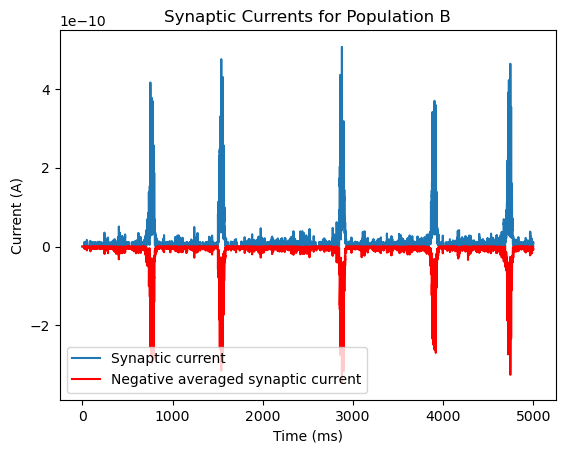

In [9]:
plt.plot(current_monitor.t / ms, current_monitor.I_syn_B[0] / amp, label="Synaptic current")


plt.plot(current_monitor.t / ms, averaged / amp, label="Negative averaged synaptic current", color='red')
plt.title('Synaptic Currents for Population B')
plt.xlabel('Time (ms)')
plt.ylabel('Current (A)')
plt.legend(loc='lower left')

# Interpretation:
* During an SWR event, the network enters a state of synchronous activation, where pyramidal cells fire rapidly, leading to increased excitatory currents.

* The temporary decrease in inhibition (negative current) is consistent with the disinhibition mechanism:

  *     Anti-SWR cells reduce their firing, allowing pyramidal cells to activate strongly.

  *  PV+ basket cells increase their activity during this period to regulate the firing, which is reflected in the rapid termination of the excitatory peak.


In [10]:
# The method create_butter_bandpass creates a Butterworth digital filter with specified parameters.
# This filter can then be applied to signals for band-pass, low-pass.
# Original authors: Evangelista et al. (2022), taken from https://github.com/robyeva/SWR_generation_disinhibition/tree/master

def create_butter_bandpass(lowcut, highcut, fs, order=2, btype='band'):
    """create a butterworth digital filter with given order"""
    # normalize freq with Nyquist freq (to be in [0,1])
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if btype == 'band':
        b, a = butter(order, [low, high], btype=btype, analog=False)
    elif btype == 'low':
        b, a = butter(order, high, btype=btype, analog=False)
    else:
        b = 0
        a = 0
    return b, a  # a and b are coefficient filter


b_band, a_band = create_butter_bandpass(90, 180, 1e4, 2, btype="band")
band_pass = filtfilt(b_band, a_band, -averaged)

b_low, a_low = create_butter_bandpass(0, 5, 1e4, 2, btype="low")
low_pass = filtfilt(b_low, a_low, -averaged)

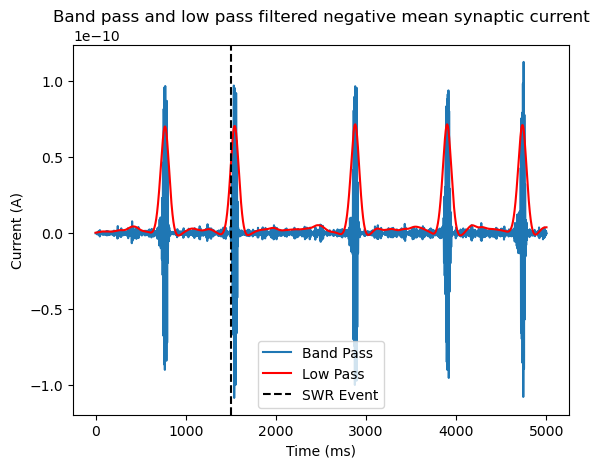

In [34]:
# plot band pass and low pass filtered negative mean synaptic current
# Similar to fig.3 in the paper
plt.plot(current_monitor.t / ms, band_pass / amp, label='Band Pass')
plt.plot(current_monitor.t / ms, low_pass / amp, label='Low Pass', color='red')
plt.axvline(x=1500, color='black', linestyle='--', label='SWR Event')
plt.title("Band pass and low pass filtered negative mean synaptic current")
plt.xlabel("Time (ms)")
plt.ylabel("Current (A)")
plt.legend()

# Implications
**SWR Detection:**

* The peak in the filtered signals indicates that the network has entered a synchronized high-activity state.

* SWRs are critical for memory consolidation, and the presence of both low and high-frequency components suggests proper event formation.
Filtering Effect:

   *   The band-pass filter isolates ripples (typically in the 90-180 Hz range), which are less visible in the raw signal.
   * The low-pass filter removes high-frequency noise, emphasizing slow-wave components of the SWR.


index: [ 7696 15419 28784 38981 47331]
peaks [7.01223083e-11 7.04795427e-11 7.15530208e-11 7.15179465e-11
 7.10586363e-11]


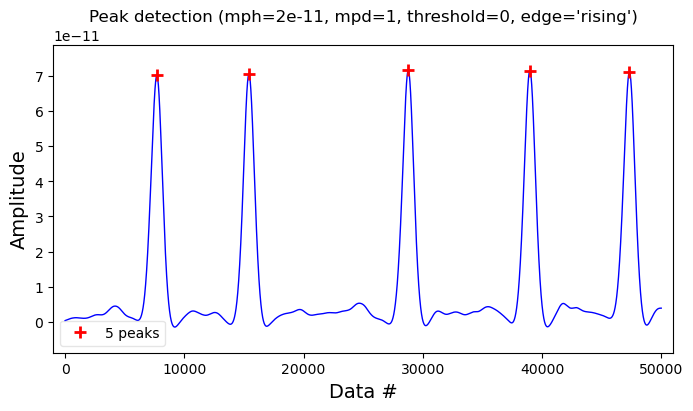

In [35]:
indx = detect_peaks(low_pass, mph=2e-11, mpd=1, threshold=0, edge='rising', valley=False, show=True)
print('index:', indx)
peaks = low_pass[indx]
print('peaks', peaks)

In [36]:
def find_onset(seq, peaks, indices, baseline_window_low, baseline_window_high, dt):
    """Find the onset of a sequence of data relative to a set of peaks"""
    baselines = []
    for peak_index in indices:
        # find the baseline
        baseline_start = max(0, int(peak_index - baseline_window_low / dt))
        baseline_end = int(peak_index - baseline_window_high / dt)
        mean_baseline = np.average(seq[baseline_start:baseline_end])
        baselines.append(mean_baseline)
    global_baseline = np.mean(baselines)

    # fwhm = [seq[seq > np.mean(p, global_baseline)] for p in peaks]
    points = []
    for idx, peak in enumerate(peaks):
        fwhm = np.mean([peak, global_baseline])
        local_seq = seq[indices[idx] - int(100 / dt):indices[idx]]
        fwhm_point = seq[np.where(local_seq > fwhm)][0]
        #fwhm_point = indices[idx] - int(100 / dt) + np.where(local_seq > fwhm)[0]
        points.append(fwhm_point)
    return points


onset_points = find_onset(low_pass, peaks, indx, 200, 100, delta_t)


In [37]:
def find_onset(seq, peaks, indices, baseline_window_low, baseline_window_high, dt):
    baselines = []
    for peak_index in indices:
        baseline_start = max(0, int(peak_index - baseline_window_low / dt))
        baseline_end = max(0, int(peak_index - baseline_window_high / dt))
        mean_baseline = np.average(seq[baseline_start:baseline_end])
        baselines.append(mean_baseline)

    global_baseline = np.mean(baselines)

    points = []
    for idx, peak in enumerate(peaks):
        fwhm = np.mean([peak, global_baseline])

        # Search within a 100 ms window before the peak
        start_idx = int(indices[idx] - 100 / dt)
        local_seq = seq[start_idx:indices[idx]]

        # Find the first point where the signal exceeds the half maximum
        try:
            onset_point = start_idx + int(np.where(local_seq > fwhm)[0][0])
            points.append(onset_point)
        except IndexError:
            print(f"Onset not found for peak at index {indices[idx]}")
            points.append(None)

    return points


onset_points = find_onset(low_pass, peaks, indx, 200, 100, delta_t)


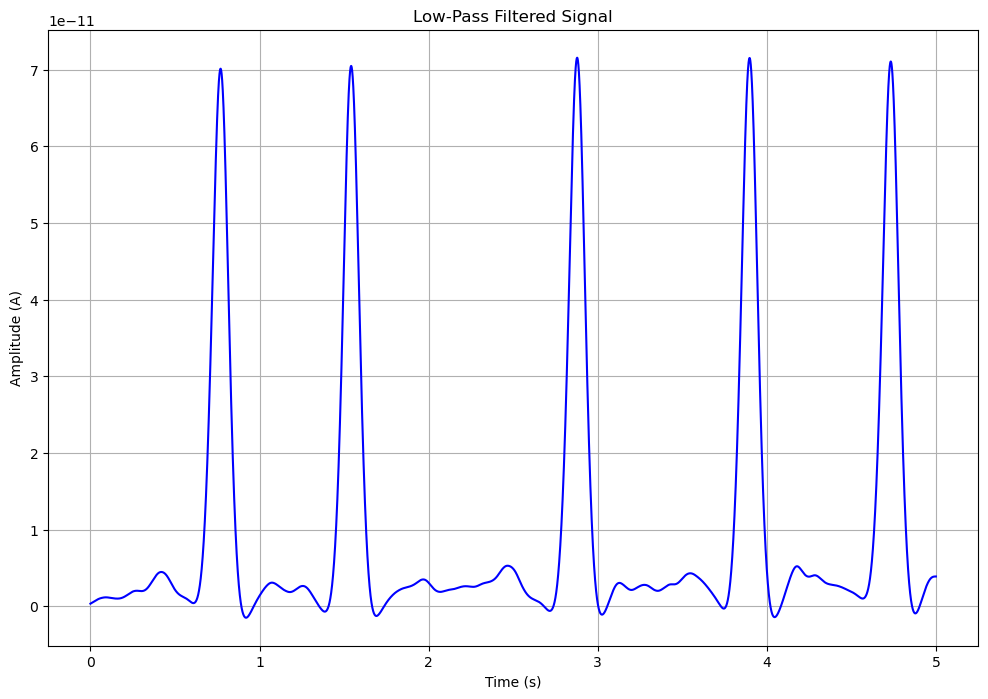

In [18]:
# Plot the low-pass filtered signal with detected onset points
plt.figure(figsize=(12, 8))
plt.plot(current_monitor.t / ms /1000, low_pass / amp, label='Low-Pass Filtered Signal', color='blue')

# plt.scatter(current_monitor.t[indx] / ms, low_pass[indx] / amp, color='red', label='SWR Peaks', zorder=3)
# plt.scatter(current_monitor.t[onset_points] / ms, low_pass[onset_points] / amp, color='green', label='Onset Points',
#             zorder=3)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude (A)')
plt.title('Low-Pass Filtered Signal')
#plt.legend()
plt.grid(True)
plt.show()


In [39]:
def find_start_and_end(seq, peak_index, half_max):
  
    start_idx = peak_index
    while start_idx > 0 and seq[start_idx] > half_max:
        start_idx -= 1

    end_idx = peak_index
    while end_idx < len(seq) and seq[end_idx] > half_max:
        end_idx += 1

    return start_idx, end_idx


In [40]:
def find_event_boundaries(seq, peaks, indices, baseline_window_low, baseline_window_high, dt):
    baselines = []
    for peak_index in indices:
        baseline_start = max(0, int(peak_index - baseline_window_low / dt))
        baseline_end = max(0, int(peak_index - baseline_window_high / dt))
        mean_baseline = np.average(seq[baseline_start:baseline_end])
        baselines.append(mean_baseline)

    global_baseline = np.mean(baselines)

    event_boundaries = []
    for idx, peak in enumerate(peaks):
        fwhm = np.mean([peak, global_baseline])
        start_idx = indices[idx]
        while start_idx > 0 and seq[start_idx] > fwhm:
            start_idx -= 1

        end_idx = indices[idx]
        while end_idx < len(seq) and seq[end_idx] > fwhm:
            end_idx += 1
        event_boundaries.append((start_idx, end_idx))
    return event_boundaries
event_boundaries = find_event_boundaries(low_pass, peaks, indx, 200, 100, delta_t)
print(event_boundaries)

[(7144, 8218), (14900, 15941), (28245, 29305), (38442, 39507), (46778, 47858)]


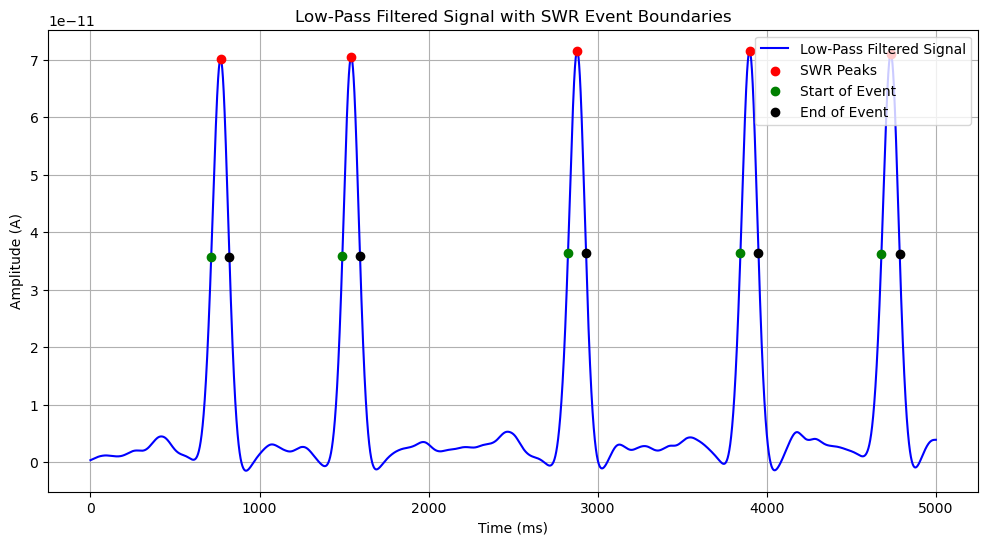

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(current_monitor.t / ms, low_pass / amp, label='Low-Pass Filtered Signal', color='blue')

plt.scatter(current_monitor.t[indx] / ms, low_pass[indx] / amp, color='red', label='SWR Peaks', zorder=3)
plt.scatter([current_monitor.t[start] / ms for start, end in event_boundaries],
            [low_pass[start] / amp for start, end in event_boundaries],
            color='green', label='Start of Event', zorder=3)
plt.scatter([current_monitor.t[end] / ms for start, end in event_boundaries],
            [low_pass[end] / amp for start, end in event_boundaries],
            color='black', label='End of Event', zorder=3)

plt.xlabel('Time (ms)')
plt.ylabel('Amplitude (A)')
plt.title('Low-Pass Filtered Signal with SWR Event Boundaries')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

[(7144, 8218), (14900, 15941), (28245, 29305), (38442, 39507), (46778, 47858)]
5


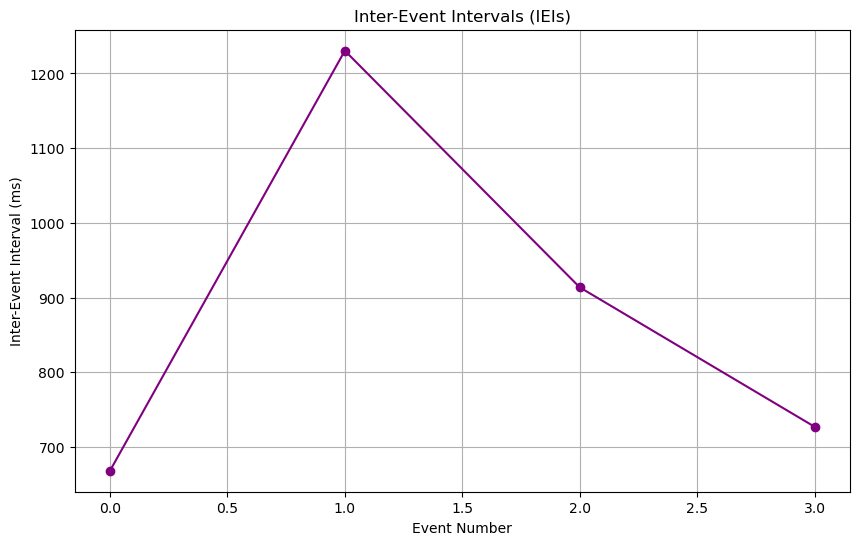

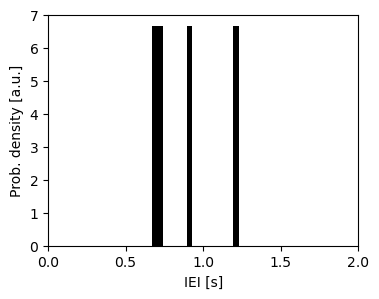

In [42]:
filtered_events = []
print(event_boundaries)
print(len(event_boundaries))
for i in range(len(event_boundaries) - 1):
    start, end = event_boundaries[i]
    next_start, _ = event_boundaries[i + 1]

    # Filter conditions
   # if low_pass[indx[i]] >= 30e-12 and (current_monitor.t[next_start] - current_monitor.t[end]) / ms > 100:
       # filtered_events.append((start, end, indx[i]))

inter_event_intervals = []
#for i in range(len(filtered_events) - 1):
for i in range(len(event_boundaries) - 1):  #TODO:SHK filtered_events
    current_end = event_boundaries[i][1]    #TODO:SHK filtered_events
    next_start = event_boundaries[i + 1][0] #TODO:SHK filtered_events
    iei = (current_monitor.t[next_start] - current_monitor.t[current_end]) / ms  # IEI in ms
    inter_event_intervals.append(iei)

plt.figure(figsize=(10, 6))
plt.plot(range(len(inter_event_intervals)), inter_event_intervals, marker='o', color='purple')
plt.xlabel('Event Number')
plt.ylabel('Inter-Event Interval (ms)')
plt.title('Inter-Event Intervals (IEIs)')
plt.grid(True)
plt.show()



# Convert to seconds
inter_event_intervals = np.array(inter_event_intervals) / 1000  

# Plot histogram with probability density
plt.figure(figsize=(4, 3))
plt.hist(inter_event_intervals, bins=15, density=True, color='black', alpha=1)

# Label axes
plt.xlabel("IEI [s]")
plt.ylabel("Prob. density [a.u.]")

# Set x-axis limits to match the example
plt.xlim(0, 2)

# Display the plot
plt.show()


In [43]:
durations = []
for event in event_boundaries:
    event_duration = event[1] - event[0]
    durations.append(event_duration * defaultclock.dt / ms)

print("Average event duration: {:.2f} ms".format(np.mean(durations)))

incidence = len(event_boundaries) / sim_length * 1000
print(f"Incidence: {incidence:.2f} events/s")

Average event duration: 106.40 ms
Incidence: 1.00 events/s


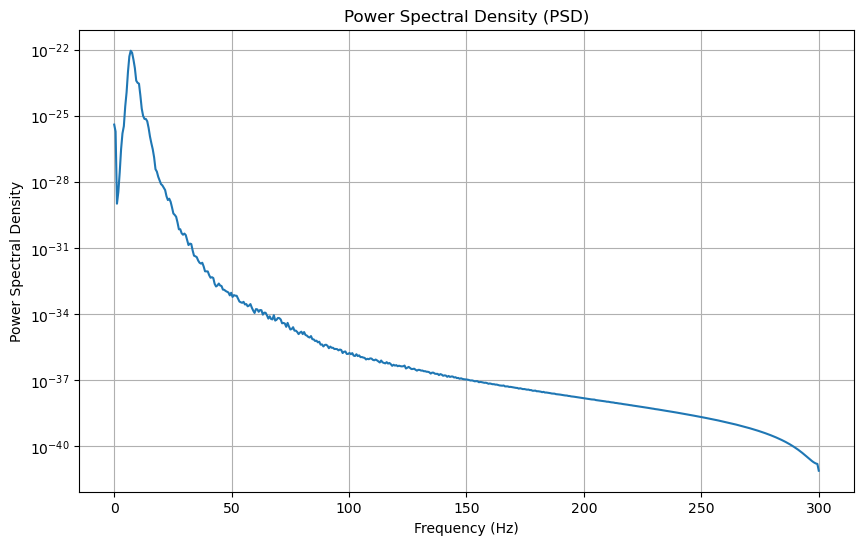

In [11]:
# Example: Simulated signal with two frequency components (50 Hz and 120 Hz)
fs = 600  # Sampling frequency (Hz)

signal = current_monitor.I_syn_B[0]

# Calculate PSD using Welch's method
frequencies, power_spectrum = welch(band_pass, fs=fs, nperseg=1024)

# Plot the PSD
plt.figure(figsize=(10, 6))
plt.semilogy(frequencies, power_spectrum)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectral Density (PSD)')
plt.grid(True)
plt.show()

In [45]:
# for each population calculate the average firing rate during swr and non swr states

#### SWR FIRING RATE ####
P_rate = pop_rate_P.smooth_rate(window="gaussian", width=2 * ms)
B_rate = pop_rate_B.smooth_rate(window="gaussian", width=2 * ms)
A_rate = pop_rate_A.smooth_rate(window="gaussian", width=2 * ms)


swr_firing_P = []
swr_firing_A = []
swr_firing_B = []
for event in event_boundaries:
    swr_firing_P.append(np.mean(P_rate[event[0]:event[1]]))
    swr_firing_B.append(np.mean(B_rate[event[0]:event[1]]))
    swr_firing_A.append(np.mean(A_rate[event[0]:event[1]]))

# The average here is a little bit lower because we defined the onset of the event as half maximum, 
# therefore also values on the up and down slope are included
print(np.mean(swr_firing_P))
print(np.mean(swr_firing_A))
print(np.mean(swr_firing_B))

#### NON SWR FIRING RATE ####
# Create a mask that is True for all time points
mask = np.ones(len(P_rate), dtype=bool)

# Set the mask to False for all indices that fall within SWR events
for start, end in event_boundaries:
    mask[start:end] = False

# Now compute the average firing rate for non-SWR periods for each population
non_swr_firing_P = np.mean(P_rate[mask])
non_swr_firing_A = np.mean(A_rate[mask])
non_swr_firing_B = np.mean(B_rate[mask])

print("Non-SWR firing rate for P:", non_swr_firing_P)
print("Non-SWR firing rate for A:", non_swr_firing_A)
print("Non-SWR firing rate for B:", non_swr_firing_B)


28.655831405913727
4.911797709693735
60.04959607104267
Non-SWR firing rate for P: 2.51107503 Hz
Non-SWR firing rate for A: 12.18838475 Hz
Non-SWR firing rate for B: 2.34411219 Hz


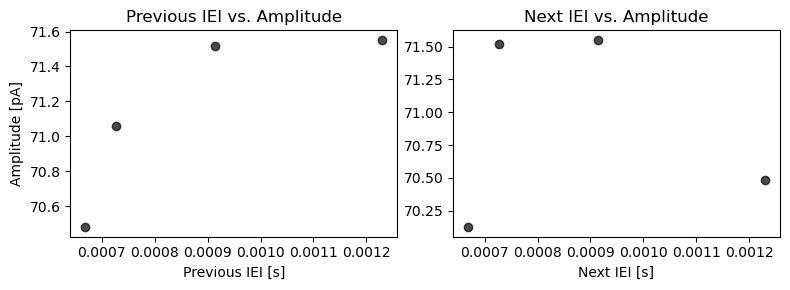

In [46]:

# Convert IEI from milliseconds to seconds
IEI_s = inter_event_intervals / 1000  


# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Plot Previous IEI correlation
axes[0].scatter(IEI_s, peaks[1:] * 1e12, color='black', alpha=0.7)
x_fit = np.linspace(0, 2, 100)
axes[0].set_xlabel("Previous IEI [s]")
axes[0].set_ylabel("Amplitude [pA]")
axes[0].set_title("Previous IEI vs. Amplitude")

# Plot Next IEI correlation (excluding last peak)
axes[1].scatter(IEI_s, peaks[:-1] * 1e12, color='black', alpha=0.7)
axes[1].set_xlabel("Next IEI [s]")

axes[1].set_title("Next IEI vs. Amplitude")

plt.tight_layout()
plt.show()
